In [ ]:
from __future__ import annotations

import json
import random
import sys
import time
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from tqdm import tqdm


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "churn_pipeline").exists() and (p / "churn-prediction-25-26").exists():
            return p
    return start


ROOT = _find_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from churn_pipeline.dataset_builder import build_datasets_cli  # noqa: E402
from churn_pipeline.transformer_user_day import (  # noqa: E402
    TrainingConfig,
    UserSequenceDataset,
    UserDayTableSequenceDataset,
    build_user_day_sequences,
    collate_batch,
    make_dataloaders,
    predict_proba,
    train_model,
 )
from churn_pipeline.resnet_transformer_user_day import (  # noqa: E402
    ChurnResNetTransformerUserDay,
 )

## 1) Configuration: cutoffs, label, feature window, model params

In [ ]:
# Data paths (self-contained in this folder: ROOT/churn-prediction-25-26)
COMPETITION_DIR = ROOT / "churn-prediction-25-26"
TRAIN_PATH = COMPETITION_DIR / "train.parquet"
TEST_PATH = COMPETITION_DIR / "test.parquet"
EXAMPLE_SUB = COMPETITION_DIR / "example_submission.csv"

# rolling cutoffs
CUTOFF_START = "2018-10-01"
CUTOFF_END = "2018-11-10"
CUTOFF_FREQ = "1D"  # "1D" | "2D" | "3D" | ...
CUT_OFFS = pd.date_range(CUTOFF_START, CUTOFF_END, freq=CUTOFF_FREQ)

# label
LABEL_MODE = "horizon"  # "horizon" | "ever"
HORIZON_DAYS = 10

# feature window: number of recent days (align with Transformer max_seq_len)
LOOKBACK_DAYS = 51

# leakage-prevention filters
EXCLUDE_PAGES = "Cancellation Confirmation,Cancel"
EXCLUDE_AUTH_VALUES = "Cancelled"

# build parameters
DROP_LAST_K_EVENTS = 0
FULL_CALENDAR = True
VAL_PROB_LOW = 0.8
VAL_PROB_HIGH = 1.0
SPLIT_SEED = "split_v1"

# Performance/cache (kept inside this folder for portability)
CACHE_DIR = ROOT / ".cache" / "user_day_features"
OUTPUT_BASE_DIR = ROOT / "data" / "processed"
BATCH_SIZE = 1_000_000
FORCE_RECOMPUTE = False

# Transformer training config (kept consistent with the original for comparability)
config = TrainingConfig(
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.5,
    max_seq_len=int(LOOKBACK_DAYS),
    batch_size=256,
    lr=1e-4,
    weight_decay=5e-3,
    epochs=25,
    use_cosine_decay=True,
    eta_min_factor=0.1,
    warmup_epochs=1,
    use_focal_loss=True,
    focal_gamma=2.0,
    early_stop_patience=3,
    early_stop_min_delta=0.0,
    pooling="mean",
 )

# ResNet stem hyperparams (key difference in this notebook)

cutoffs= 41 2018-10-01 -> 2018-11-10
device= cuda
max_seq_len= 51
resnet_depth= 3 resnet_kernel= 5


## 2) Build rolling train/val (concatenate multiple cutoff snapshots)

In [3]:
t0 = time.time()

all_train_ud = []
all_val_ud = []
all_labels = []

for cutoff in tqdm(CUT_OFFS, desc='build rolling cutoffs'):
    cutoff_str = str(pd.Timestamp(cutoff).date())
    paths = build_datasets_cli(
        train_path=str(TRAIN_PATH),
        test_path=str(TEST_PATH),
        output_dir=None,
        output_base_dir=str(OUTPUT_BASE_DIR),
        cache_dir=str(CACHE_DIR),
        cutoff_time=cutoff_str,
        horizon_days=int(HORIZON_DAYS),
        label_mode=str(LABEL_MODE),
        drop_last_k_events=int(DROP_LAST_K_EVENTS),
        exclude_pages=str(EXCLUDE_PAGES),
        exclude_auth_values=str(EXCLUDE_AUTH_VALUES),
        val_prob_low=float(VAL_PROB_LOW),
        val_prob_high=float(VAL_PROB_HIGH),
        split_seed=str(SPLIT_SEED),
        batch_size=int(BATCH_SIZE),
        full_calendar=bool(FULL_CALENDAR),
        force_recompute=bool(FORCE_RECOMPUTE),
        verbose=False,
    )

    train_ud = pd.read_parquet(paths['train_features'])
    val_ud = pd.read_parquet(paths['val_features'])
    train_lab = pd.read_parquet(paths['train_labels'])[['userId', 'label']]
    val_lab = pd.read_parquet(paths['val_labels'])[['userId', 'label']]

    end_day = pd.Timestamp(cutoff).normalize() - pd.Timedelta(days=1)
    start_day = end_day - pd.Timedelta(days=int(LOOKBACK_DAYS) - 1)

    def _slice(df: pd.DataFrame) -> pd.DataFrame:
        d = pd.to_datetime(df['day']).dt.normalize()
        return df.loc[(d >= start_day) & (d <= end_day)].copy()

    train_ud = _slice(train_ud)
    val_ud = _slice(val_ud)

    suffix = '|' + cutoff_str
    train_ud['userId'] = train_ud['userId'].astype(str) + suffix
    val_ud['userId'] = val_ud['userId'].astype(str) + suffix
    train_lab['userId'] = train_lab['userId'].astype(str) + suffix
    val_lab['userId'] = val_lab['userId'].astype(str) + suffix

    all_train_ud.append(train_ud)
    all_val_ud.append(val_ud)
    all_labels.append(pd.concat([train_lab, val_lab], axis=0, ignore_index=True))

train_ud_all = pd.concat(all_train_ud, axis=0, ignore_index=True)
val_ud_all = pd.concat(all_val_ud, axis=0, ignore_index=True)
labels_all = pd.concat(all_labels, axis=0, ignore_index=True)

labels_dict = {str(uid): int(y) for uid, y in zip(labels_all['userId'].astype(str), labels_all['label'].astype(int))}

print('train_ud_all', train_ud_all.shape, 'val_ud_all', val_ud_all.shape)
print('labels_all', labels_all.shape, 'unique labels keys', len(labels_dict))
print('seconds', round(time.time() - t0, 2))
(train_ud_all.head(), val_ud_all.head(), labels_all.head())

build rolling cutoffs: 100%|██████████| 41/41 [00:50<00:00,  1.23s/it]


train_ud_all (12523860, 105) val_ud_all (3170940, 105)
labels_all (784740, 2) unique labels keys 784740
seconds 51.6


(               userId        day  d_events  d_sessions  d_pages_unique  \
 0  1000025|2018-10-02 2018-10-01         0           0               0   
 1  1000035|2018-10-02 2018-10-01         0           0               0   
 2  1000083|2018-10-02 2018-10-01        14           1               3   
 3  1000103|2018-10-02 2018-10-01         0           0               0   
 4  1000164|2018-10-02 2018-10-01         2           1               2   
 
    d_active_hours  d_first_hour  d_last_hour  d_nextsong_cnt  \
 0               0            -1           -1               0   
 1               0            -1           -1               0   
 2               3             5           11              11   
 3               0            -1           -1               0   
 4               1            17           17               1   
 
    d_listen_sec_sum  ...  x_active_streak  d_events_per_session  \
 0          0.000000  ...                0                   0.0   
 1          0.000000

## 3) Build test with a fixed cutoff (for submission)

In [4]:
SUBMISSION_CUTOFF = str(pd.Timestamp(CUTOFF_END).date())

sub_paths = build_datasets_cli(
    train_path=str(TRAIN_PATH),
    test_path=str(TEST_PATH),
    output_dir=None,
    output_base_dir=str(OUTPUT_BASE_DIR),
    cache_dir=str(CACHE_DIR),
    cutoff_time=SUBMISSION_CUTOFF,
    horizon_days=int(HORIZON_DAYS),
    label_mode=str(LABEL_MODE),
    drop_last_k_events=int(DROP_LAST_K_EVENTS),
    exclude_pages=str(EXCLUDE_PAGES),
    exclude_auth_values=str(EXCLUDE_AUTH_VALUES),
    val_prob_low=float(VAL_PROB_LOW),
    val_prob_high=float(VAL_PROB_HIGH),
    split_seed=str(SPLIT_SEED),
    batch_size=int(BATCH_SIZE),
    full_calendar=bool(FULL_CALENDAR),
    force_recompute=bool(FORCE_RECOMPUTE),
    verbose=False,
)

test_ud = pd.read_parquet(sub_paths['test_features'])
cutoff_ts = pd.Timestamp(SUBMISSION_CUTOFF).normalize()
end_day = cutoff_ts - pd.Timedelta(days=1)
start_day = end_day - pd.Timedelta(days=int(LOOKBACK_DAYS) - 1)
d = pd.to_datetime(test_ud['day']).dt.normalize()
test_ud = test_ud.loc[(d >= start_day) & (d <= end_day)].copy()

print('test_ud', test_ud.shape, 'window', str(start_day.date()), '->', str(end_day.date()))
test_ud.head()

test_ud (116160, 105) window 2018-09-20 -> 2018-11-09


,userId,day,d_events,d_sessions,d_pages_unique,d_active_hours,d_first_hour,d_last_hour,d_nextsong_cnt,d_listen_sec_sum,...,x_active_streak,d_events_per_session,d_nextsong_per_session,x_roll7_std_events,x_roll7_std_listen_sec_mean,d_day_of_week,x_today_over_roll7_events_mean,x_today_over_roll7_nextsong_mean,x_roll7_minus_roll28_events_mean,x_roll7_minus_roll28_nextsong_mean
0,1000655,2018-10-01,0,0,0,0,-1,-1,0,0.000000,...,0,0.0,0.0,0.000000,0.000000,0,0.0,0.000000,0.000000,0.000000
1,1000655,2018-10-02,0,0,0,0,-1,-1,0,0.000000,...,0,0.0,0.0,0.000000,0.000000,1,0.0,0.000000,0.000000,0.000000
2,1000655,2018-10-03,39,1,6,3,9,11,31,8547.356445,...,1,39.0,31.0,13.647158,96.482307,2,7.0,7.000000,4.178572,3.321428
3,1000655,2018-10-04,0,0,0,0,-1,-1,0,0.000000,...,0,0.0,0.0,13.647158,96.482307,3,0.0,0.000000,4.178572,3.321428
4,1000655,2018-10-05,31,1,7,2,22,23,23,7123.059082,...,1,31.0,23.0,15.955296,132.544189,4,3.1,2.981481,7.500000,5.785714


## 4) Numeric feature processing: drop constant cols + log1p/clip + StandardScaler

In [5]:
# Memory-lean numeric preprocessing (avoid `.copy()` and huge dense matrices)
# NOTE: this modifies train_ud_all/val_ud_all in-place through these references.
train_ud = train_ud_all
val_ud = val_ud_all

feature_cols = sorted([c for c in train_ud.columns if c not in {'userId', 'day'}])

# 1) drop train constant cols (cheaper than nunique on huge tables)
mins = train_ud[feature_cols].min(skipna=True)
maxs = train_ud[feature_cols].max(skipna=True)

keep_cols = []
for c in feature_cols:
    mn = mins.get(c)
    mx = maxs.get(c)
    # drop all-NaN or constant columns
    if (pd.isna(mn) and pd.isna(mx)) or (mn == mx):
        continue
    keep_cols.append(c)

drop_cols = [c for c in feature_cols if c not in set(keep_cols)]
print('drop constant cols:', len(drop_cols))
feature_cols = keep_cols

# 2) log1p + clip (count / sum-like features)
def _is_count_like(col: str) -> bool:
    if col.endswith('_cnt') or col.endswith('_sum'):
        return True
    if col.endswith('_active_days') or col.endswith('_paid_days'):
        return True
    if col in {
        'd_events',
        'd_sessions',
        'd_pages_unique',
        'd_active_hours',
        'd_nextsong_cnt',
        'd_listen_sec_sum',
        'd_level_free_cnt',
        'd_level_paid_cnt',
    }:
        return True
    return False

count_like = [c for c in feature_cols if _is_count_like(str(c))]
print('count_like:', len(count_like))

clip_q = 0.995

def _iter_blocks(items: list[str], block_size: int = 32):
    for i in range(0, len(items), int(block_size)):
        yield items[i : i + int(block_size)]

# compute clip_upper in small blocks to reduce peak memory during quantile
if count_like:
    _clip = {}
    for cols in _iter_blocks(count_like, block_size=32):
        q = train_ud[cols].quantile(clip_q, interpolation='linear')
        for c in cols:
            v = float(q.loc[c])
            _clip[c] = max(0.0, v)
    clip_upper = pd.Series(_clip)
else:
    clip_upper = pd.Series(dtype=float)

def _ensure_float32(df: pd.DataFrame, cols: list[str]) -> None:
    for c in cols:
        if c in df.columns and df[c].dtype != np.float32:
            df[c] = df[c].astype(np.float32)

def _log1p_clip_inplace(df: pd.DataFrame) -> None:
    if not count_like:
        return
    _ensure_float32(df, count_like)
    for c in count_like:
        arr = df[c].to_numpy(copy=False)
        np.maximum(arr, 0.0, out=arr)
        up = float(clip_upper.get(c, np.inf))
        if np.isfinite(up):
            np.minimum(arr, up, out=arr)
        np.log1p(arr, out=arr)

_log1p_clip_inplace(train_ud)
_log1p_clip_inplace(val_ud)
_log1p_clip_inplace(test_ud)

# 3) Standardize (fit on train only) without building a huge dense matrix
mu = train_ud[feature_cols].mean(skipna=True)
std = train_ud[feature_cols].std(skipna=True, ddof=0)

means = mu.reindex(feature_cols).to_numpy(dtype=np.float32)
scales = std.reindex(feature_cols).to_numpy(dtype=np.float32)
scales = np.where(np.isfinite(scales) & (scales > 0), scales, 1.0).astype(np.float32)

def _standardize_inplace(df: pd.DataFrame) -> None:
    _ensure_float32(df, feature_cols)
    for c, m, s in zip(feature_cols, means, scales):
        arr = df[c].to_numpy(copy=False)
        np.subtract(arr, m, out=arr)
        np.divide(arr, s, out=arr)

_standardize_inplace(train_ud)
_standardize_inplace(val_ud)
_standardize_inplace(test_ud)

# Save scaler params for later serialization/repro (matches sklearn fields)
scaler_payload = {
    'mean_': means.astype(float).tolist(),
    'scale_': scales.astype(float).tolist(),
    'var_': (scales.astype(np.float64) ** 2).tolist(),
    'n_features_in_': int(len(feature_cols)),
}

(train_ud.shape, val_ud.shape, test_ud.shape, len(feature_cols))

drop constant cols: 5
count_like: 45


((12523860, 105), (3170940, 105), (116160, 105), 98)

## 5) Build sequence dataset + DataLoader

In [6]:
# pos_weight (kept consistent with the original notebook for comparability)
pos_weight = 7

# Memory-lean: avoid materializing `train_sequences/val_sequences/test_sequences` (big dict of arrays).
# Build lazy datasets directly from the user-day tables.
train_dataset = UserDayTableSequenceDataset(
    train_ud,
    feature_cols,
    config.max_seq_len,
    labels=labels_dict,
    assume_sorted=False,
 )
val_dataset = UserDayTableSequenceDataset(
    val_ud,
    feature_cols,
    config.max_seq_len,
    labels=labels_dict,
    assume_sorted=False,
 )
test_dataset = UserDayTableSequenceDataset(
    test_ud,
    feature_cols,
    config.max_seq_len,
    labels=None,
    assume_sorted=False,
 )

len(train_dataset), len(val_dataset), len(test_dataset)

(610920, 154680, 2904)

## 6) Train ResNet+Transformer (multi-seed soft vote) + validate AUC

train_model:   0%|          | 0/25 [00:00<?, ?it/s]/Data/yuhan.wu/miniconda3/envs/py310/lib/python3.10/site-packages/torch/nn/functional.py:5699: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  proj = linear(q, w, b)
/Data/yuhan.wu/miniconda3/envs/py310/lib/python3.10/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDetermi

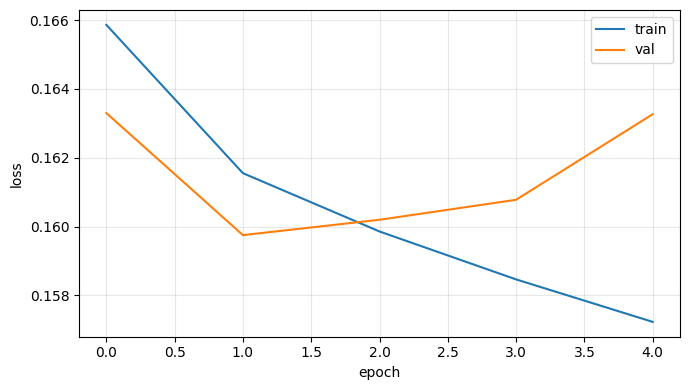

train_model:   0%|          | 0/25 [00:00<?, ?it/s]/Data/yuhan.wu/miniconda3/envs/py310/lib/python3.10/site-packages/torch/nn/functional.py:5699: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:304.)
  proj = linear(q, w, b)
/Data/yuhan.wu/miniconda3/envs/py310/lib/python3.10/site-packages/torch/nn/modules/linear.py:134: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDetermi

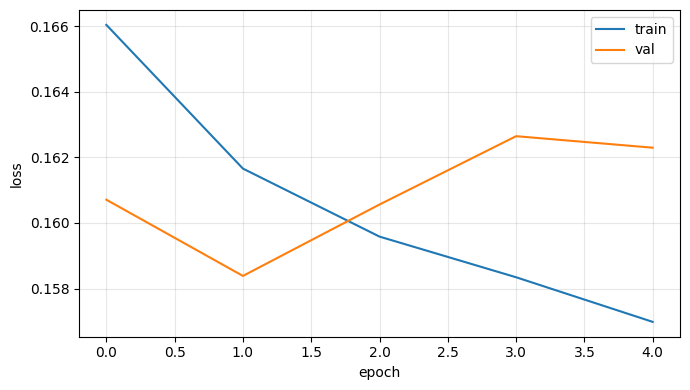

predict_proba: 100%|██████████| 12/12 [00:00<00:00, 111.27it/s]


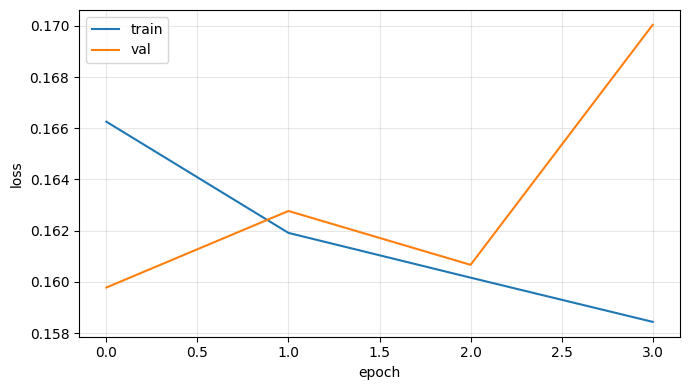

0.7334433868169561

In [7]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # For run-to-run stability (esp. on GPU).
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


val_prob_by_seed = []
test_prob_by_seed = []
best_states = []

# Keep stable key order for ensembling/metrics
val_keys = list(val_dataset.user_ids)
test_keys = list(test_dataset.user_ids)

for seed in SEEDS:
    set_seed(int(seed))
    gen = torch.Generator()
    gen.manual_seed(int(seed))

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        collate_fn=collate_batch,
        generator=gen,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        collate_fn=collate_batch,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        collate_fn=collate_batch,
    )

    model = ChurnResNetTransformerUserDay(
        num_numeric=len(feature_cols),
        config=config,
        resnet_depth=int(RESNET_DEPTH),
        resnet_kernel_size=int(RESNET_KERNEL),
    ).to(device)

    train_losses, val_losses, model, best_epoch, best_state = train_model(
        model,
        train_loader,
        val_loader,
        device,
        epochs=int(config.epochs),
        lr=float(config.lr),
        weight_decay=float(config.weight_decay),
        pos_weight=float(pos_weight),
        use_cosine_decay=bool(config.use_cosine_decay),
        eta_min_factor=float(config.eta_min_factor),
        warmup_epochs=int(config.warmup_epochs),
        use_focal_loss=bool(config.use_focal_loss),
        focal_gamma=float(config.focal_gamma),
        early_stop_patience=int(config.early_stop_patience),
        early_stop_min_delta=float(config.early_stop_min_delta),
    )

    val_probs = predict_proba(model, val_loader, device)
    test_probs = predict_proba(model, test_loader, device)

    val_prob_by_seed.append(val_probs)
    test_prob_by_seed.append(test_probs)
    best_states.append({'seed': int(seed), 'best_epoch': int(best_epoch), 'state_dict': best_state})

    import matplotlib.pyplot as plt
    plt.figure(figsize=(7, 4))
    plt.plot(train_losses, label="train")
    plt.plot(val_losses, label="val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

val_proba_mean = np.mean([[d[k] for k in val_keys] for d in val_prob_by_seed], axis=0)
test_proba_mean = np.mean([[d[k] for k in test_keys] for d in test_prob_by_seed], axis=0)

y_val = np.array([labels_dict[k] for k in val_keys], dtype=int)
val_auc = float(roc_auc_score(y_val, val_proba_mean))
val_auc

## 7) Choose threshold (Balanced Accuracy)

In [8]:
thresholds = np.linspace(0.01, 0.99, 99)
bal_scores = [balanced_accuracy_score(y_val, (val_proba_mean >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(bal_scores))
best_thr = float(thresholds[best_idx])
best_bal = float(bal_scores[best_idx])
best_thr, best_bal

(0.41000000000000003, 0.6731390926004945)

## 8) Generate submission (id,target)

In [9]:
thr = float(best_thr)

pred = pd.DataFrame({'id': np.array(test_keys, dtype=int), 'proba': test_proba_mean.astype(float)})
example = pd.read_csv(EXAMPLE_SUB)
out = example[['id']].merge(pred, on='id', how='left')
out['proba'] = out['proba'].fillna(0.0)
out['target'] = (out['proba'] >= thr).astype(int)
out = out[['id', 'target']]

print('test predicted positive rate:', float(out['target'].mean()))
out.head()

test predicted positive rate: 0.4108126721763085


,id,target
0,1128274,0
1,1782451,0
2,1611542,0
3,1241663,1
4,1653104,0


## 9) Save artifacts and submission files (experiments/transformer_rolling/)

In [ ]:
run_name = (
    f"resnet_transformer_rolling_nb_cut{CUTOFF_START}-{CUTOFF_END}_{CUTOFF_FREQ}_"
    f"sub{SUBMISSION_CUTOFF}_h{HORIZON_DAYS}_lb{LOOKBACK_DAYS}_"
    f"rd{RESNET_DEPTH}_k{RESNET_KERNEL}_s{len(SEEDS)}_thr{best_thr:.3f}"
)

# Write outputs under this folder (ROOT = portable experiment root)
ART_DIR = ROOT / "artifacts" / run_name
SUB_DIR = ROOT / "submissions"
ART_DIR.mkdir(parents=True, exist_ok=True)
SUB_DIR.mkdir(parents=True, exist_ok=True)

for item in best_states:
    sd = {k: v for k, v in item.items() if k != "state_dict"}
    torch.save(item["state_dict"], ART_DIR / f"model_seed{item['seed']}.pt")
    (ART_DIR / f"model_seed{item['seed']}.json").write_text(
        json.dumps(sd, ensure_ascii=False, indent=2), encoding="utf-8"
    )

(ART_DIR / "training_config.json").write_text(
    json.dumps(asdict(config), ensure_ascii=False, indent=2), encoding="utf-8"
 )
(ART_DIR / "feature_columns.json").write_text(
    json.dumps(list(feature_cols), ensure_ascii=False, indent=2), encoding="utf-8"
 )

# NOTE: scaler_payload is produced in the preprocessing cell (memory-lean standardization)
(ART_DIR / "scaler.json").write_text(
    json.dumps(scaler_payload, ensure_ascii=False, indent=2), encoding="utf-8"
 )

meta = {
    "run_name": run_name,
    "model": "ChurnResNetTransformerUserDay",
    "resnet_depth": int(RESNET_DEPTH),
    "resnet_kernel": int(RESNET_KERNEL),
    "cutoffs": [str(pd.Timestamp(c).date()) for c in CUT_OFFS],
    "submission_cutoff": SUBMISSION_CUTOFF,
    "lookback_days": int(LOOKBACK_DAYS),
    "horizon_days": int(HORIZON_DAYS),
    "label_mode": str(LABEL_MODE),
    "seeds": [int(s) for s in SEEDS],
    "val_auc": float(val_auc),
    "best_thr_bal": float(best_thr),
    "best_bal_acc": float(best_bal),
    "num_features": int(len(feature_cols)),
    "train_rows_user_day": int(train_ud.shape[0]),
    "val_rows_user_day": int(val_ud.shape[0]),
    "pos_weight": float(pos_weight),
}
(ART_DIR / "train_meta.json").write_text(
    json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8"
 )

sub_path = SUB_DIR / f"{run_name}.csv"
out.to_csv(sub_path, index=False)

ART_DIR, sub_path

(PosixPath('/Data/yuhan.wu/kaggle_project_new/experiments/transformer_rolling/experiments/transformer_rolling/artifacts/resnet_transformer_rolling_nb_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_rd3_k5_s3_thr0.410'),
 PosixPath('/Data/yuhan.wu/kaggle_project_new/experiments/transformer_rolling/experiments/transformer_rolling/submissions/resnet_transformer_rolling_nb_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_rd3_k5_s3_thr0.410.csv'))

In [ ]:
# Optional: submit to Kaggle (requires ~/.kaggle/kaggle.json)
import sys

# In the portable folder, kaggle_submit.py is located under ROOT
sys.path.insert(0, str(ROOT))

from kaggle_submit import submit_and_track

competition = "churn-prediction-25-26"
message = f"resnet_transformer_rolling_nb submission {run_name}"
info = submit_and_track(
    sub_path,
    competition=competition,
    message=message,
 )
info

Submitting /Data/yuhan.wu/kaggle_project_new/experiments/transformer_rolling/experiments/transformer_rolling/submissions/resnet_transformer_rolling_nb_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_rd3_k5_s3_thr0.410.csv to churn-prediction-25-26 with note: resnet_transformer_rolling_nb submission resnet_transformer_rolling_nb_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_rd3_k5_s3_thr0.410


100%|██████████| 28.4k/28.4k [00:00<00:00, 62.7kB/s]


Poll 1/8: status=complete score=0.6486


{'ref': 49066734,
 'description': 'resnet_transformer_rolling_nb submission resnet_transformer_rolling_nb_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_rd3_k5_s3_thr0.410',
 'status': 'complete',
 'score': 0.6486,
 'fileName': 'resnet_transformer_rolling_nb_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_rd3_k5_s3_thr0.410.csv',
 'submissionDate': datetime.datetime(2025, 12, 14, 19, 6, 3, 917000),
 'error': '',
 'teamName': 'Yuhan Wu',
 'submittedBy': 'yuhanwu1003',
 'isFrozen': True}